# Modulo 3: Ventanas por Persona

Este Notebook toma los tracks limpios del Modulo 2 y construye mosaicos temporales por `sample_id`

## Librerias y parametros de mosaicos


In [6]:
from pathlib import Path
import json

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

VIDEO_MANIFEST_PATH = PROJECT_ROOT / "outputs" / "tracking" / "video_manifest_tracking_15pct.csv"
TRACKING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "tracking"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "person_windows"

PERSON_WINDOW_SECONDS = 3.0
PERSON_WINDOW_STRIDE_SECONDS = 1.5
FRAMES_PER_PERSON_WINDOW = 9
GRID_ROWS = 3
GRID_COLS = 3
CROP_WIDTH = 96
CROP_HEIGHT = 96
BBOX_PADDING_RATIO = 0.10
MIN_TRACK_LENGTH_FRAMES = 8
MIN_VALID_FRAMES_PER_WINDOW = 7
SAVE_DEBUG_EXAMPLES = True

pd.Series(
    {
        "VIDEO_MANIFEST_PATH": str(VIDEO_MANIFEST_PATH),
        "TRACKING_OUTPUT_DIR": str(TRACKING_OUTPUT_DIR),
        "OUTPUT_DIR": str(OUTPUT_DIR),
        "PERSON_WINDOW_SECONDS": PERSON_WINDOW_SECONDS,
        "PERSON_WINDOW_STRIDE_SECONDS": PERSON_WINDOW_STRIDE_SECONDS,
        "FRAMES_PER_PERSON_WINDOW": FRAMES_PER_PERSON_WINDOW,
        "GRID_ROWS": GRID_ROWS,
        "GRID_COLS": GRID_COLS,
        "CROP_WIDTH": CROP_WIDTH,
        "CROP_HEIGHT": CROP_HEIGHT,
        "BBOX_PADDING_RATIO": BBOX_PADDING_RATIO,
        "MIN_TRACK_LENGTH_FRAMES": MIN_TRACK_LENGTH_FRAMES,
        "MIN_VALID_FRAMES_PER_WINDOW": MIN_VALID_FRAMES_PER_WINDOW,
        "SAVE_DEBUG_EXAMPLES": SAVE_DEBUG_EXAMPLES,
    }
)


VIDEO_MANIFEST_PATH             c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
TRACKING_OUTPUT_DIR             c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
OUTPUT_DIR                      c:\Users\franco\Downloads\1-INTELIGENCIA_ARTIF...
PERSON_WINDOW_SECONDS                                                         3.0
PERSON_WINDOW_STRIDE_SECONDS                                                  1.5
FRAMES_PER_PERSON_WINDOW                                                        9
GRID_ROWS                                                                       3
GRID_COLS                                                                       3
CROP_WIDTH                                                                     96
CROP_HEIGHT                                                                    96
BBOX_PADDING_RATIO                                                            0.1
MIN_TRACK_LENGTH_FRAMES                                                         8
MIN_VALID_FRAMES

## Manifest de entrada y cobertura del subset


In [7]:
video_manifest_df = pd.read_csv(VIDEO_MANIFEST_PATH)
video_manifest_df = video_manifest_df.sort_values(["split", "class_name", "video_id"]).reset_index(drop=True)

print(f"Videos en el manifest usado por Modulo 3: {len(video_manifest_df)}")
display(video_manifest_df.groupby(["split", "class_name"]).size().reset_index(name="num_videos"))
display(video_manifest_df.head())

Videos en el manifest usado por Modulo 3: 51


,split,class_name,num_videos
0,test,hurto_simulado,3
1,test,normal,5
2,train,hurto_simulado,12
3,train,normal,23
4,val,hurto_simulado,3
5,val,normal,5


,split,class_name,video_path,video_id,fps_original,frame_count,duration_seconds,width,height
0,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_46.mp4,test__hurto_simulado__shop_lifter_46,24.75,322,13.010101,704,576
1,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_80.mp4,test__hurto_simulado__shop_lifter_80,24.75,223,9.010101,704,576
2,test,hurto_simulado,data/test/hurto_simulado/shop_lifter_95.mp4,test__hurto_simulado__shop_lifter_95,25.00,400,16.000000,704,576
3,test,normal,data/test/normal/shop_lifter_n_0_1.mp4,test__normal__shop_lifter_n_0_1,25.00,450,18.000000,704,576
4,test,normal,data/test/normal/shop_lifter_n_10.mp4,test__normal__shop_lifter_n_10,25.00,475,19.000000,704,576


## Video de referencia con trayectorias limpias


In [8]:
all_tracks_clean_path = TRACKING_OUTPUT_DIR / "all_tracks_clean.csv"

try:
    all_tracks_clean_df = pd.read_csv(all_tracks_clean_path)
except FileNotFoundError:
    track_parts = []
    for _, video_row in video_manifest_df.iterrows():
        split_name = str(video_row["split"])
        video_id = str(video_row["video_id"])
        tracks_clean_path = TRACKING_OUTPUT_DIR / split_name / video_id / "tracks_clean.csv"
        if tracks_clean_path.exists():
            track_parts.append(pd.read_csv(tracks_clean_path))
    all_tracks_clean_df = pd.concat(track_parts, ignore_index=True) if track_parts else pd.DataFrame()

if all_tracks_clean_df.empty:
    raise RuntimeError("No hay tracks limpios disponibles para construir mosaicos.")

tracked_videos_df = (
    all_tracks_clean_df.groupby(["split", "class_name", "video_id", "video_path"])
    .agg(
        num_detections=("frame_idx", "size"),
        num_tracks=("track_id", "nunique"),
    )
    .reset_index()
    .sort_values(["num_detections", "num_tracks"], ascending=False)
    .reset_index(drop=True)
)

display(
    tracked_videos_df.groupby(["split", "class_name"])
    .agg(
        videos_con_tracks=("video_id", "nunique"),
        detecciones_totales=("num_detections", "sum"),
        tracks_promedio=("num_tracks", "mean"),
        tracks_max=("num_tracks", "max"),
    )
    .round(2)
    .reset_index()
)

video_row = tracked_videos_df.iloc[0]
tracks_clean_path = TRACKING_OUTPUT_DIR / str(video_row["split"]) / str(video_row["video_id"]) / "tracks_clean.csv"
tracks_df = pd.read_csv(tracks_clean_path)
track_lengths_df = (
    tracks_df.groupby("track_id")
    .size()
    .reset_index(name="num_detections")
    .sort_values("num_detections", ascending=False)
    .reset_index(drop=True)
)

print(f"Video de referencia: {video_row['video_id']}")
display(track_lengths_df.head(10))

,split,class_name,videos_con_tracks,detecciones_totales,tracks_promedio,tracks_max
0,test,hurto_simulado,3,740,1.67,2
1,test,normal,5,1436,1.00,1
2,train,hurto_simulado,12,2704,1.58,3
3,train,normal,22,4184,1.45,4
4,val,hurto_simulado,3,687,1.67,2
5,val,normal,4,1096,1.00,1


Video de referencia: test__normal__shop_lifter_n_10


,track_id,num_detections
0,33,447


## Estadisticas de bounding boxes


In [9]:
bbox_stats_df = all_tracks_clean_df.copy()
bbox_stats_df[["bbox_width", "bbox_height"]] = bbox_stats_df[["bbox_width", "bbox_height"]].apply(pd.to_numeric, errors="coerce")
bbox_stats_df = bbox_stats_df.dropna(subset=["bbox_width", "bbox_height"]).copy()

bbox_stats_df["padded_bbox_width"] = bbox_stats_df["bbox_width"] * (1 + 2 * BBOX_PADDING_RATIO)
bbox_stats_df["padded_bbox_height"] = bbox_stats_df["bbox_height"] * (1 + 2 * BBOX_PADDING_RATIO)

overall_bbox_stats = pd.Series(
    {
        "detecciones_con_bbox": int(len(bbox_stats_df)),
        "bbox_width_promedio_px": round(float(bbox_stats_df["bbox_width"].mean()), 2),
        "bbox_width_max_px": round(float(bbox_stats_df["bbox_width"].max()), 2),
        "bbox_height_promedio_px": round(float(bbox_stats_df["bbox_height"].mean()), 2),
        "bbox_height_max_px": round(float(bbox_stats_df["bbox_height"].max()), 2),
        "bbox_width_con_padding_promedio_px": round(float(bbox_stats_df["padded_bbox_width"].mean()), 2),
        "bbox_width_con_padding_max_px": round(float(bbox_stats_df["padded_bbox_width"].max()), 2),
        "bbox_height_con_padding_promedio_px": round(float(bbox_stats_df["padded_bbox_height"].mean()), 2),
        "bbox_height_con_padding_max_px": round(float(bbox_stats_df["padded_bbox_height"].max()), 2),
    }
)

bbox_stats_by_group_df = (
    bbox_stats_df.groupby(["split", "class_name"])
    .agg(
        detecciones=("frame_idx", "size"),
        bbox_width_promedio_px=("bbox_width", "mean"),
        bbox_width_max_px=("bbox_width", "max"),
        bbox_height_promedio_px=("bbox_height", "mean"),
        bbox_height_max_px=("bbox_height", "max"),
        bbox_width_con_padding_promedio_px=("padded_bbox_width", "mean"),
        bbox_width_con_padding_max_px=("padded_bbox_width", "max"),
        bbox_height_con_padding_promedio_px=("padded_bbox_height", "mean"),
        bbox_height_con_padding_max_px=("padded_bbox_height", "max"),
    )
    .round(2)
    .reset_index()
)

display(overall_bbox_stats.to_frame(name="valor"))
display(bbox_stats_by_group_df)


,valor
detecciones_con_bbox,10847.00
bbox_width_promedio_px,54.80
bbox_width_max_px,144.82
bbox_height_promedio_px,186.89
bbox_height_max_px,392.78
bbox_width_con_padding_promedio_px,65.76
bbox_width_con_padding_max_px,173.79
bbox_height_con_padding_promedio_px,224.27
bbox_height_con_padding_max_px,471.33


,split,class_name,detecciones,bbox_width_promedio_px,bbox_width_max_px,bbox_height_promedio_px,bbox_height_max_px,bbox_width_con_padding_promedio_px,bbox_width_con_padding_max_px,bbox_height_con_padding_promedio_px,bbox_height_con_padding_max_px
0,test,hurto_simulado,740,51.62,109.43,185.84,286.42,61.94,131.31,223.01,343.70
1,test,normal,1436,42.41,84.84,161.44,236.56,50.90,101.80,193.72,283.88
2,train,hurto_simulado,2704,55.60,122.58,186.06,380.26,66.72,147.10,223.28,456.31
3,train,normal,4184,60.16,144.82,196.58,392.78,72.20,173.79,235.89,471.33
4,val,hurto_simulado,687,44.63,96.70,162.80,226.16,53.55,116.04,195.36,271.39
5,val,normal,1096,57.08,123.68,201.10,355.17,68.49,148.42,241.32,426.20


## Track de referencia


In [10]:
selected_track_id = int(track_lengths_df.iloc[0]["track_id"])
selected_track_df = (
    tracks_df[tracks_df["track_id"] == selected_track_id]
    .copy()
    .sort_values(["frame_idx", "timestamp_sec"])
    .drop_duplicates(subset=["frame_idx"], keep="first")
    .reset_index(drop=True)
)

display(
    selected_track_df.groupby("track_id")
    .agg(
        num_detections=("frame_idx", "size"),
        start_frame=("frame_idx", "min"),
        end_frame=("frame_idx", "max"),
        start_sec=("timestamp_sec", "min"),
        end_sec=("timestamp_sec", "max"),
    )
    .reset_index()
)


,track_id,num_detections,start_frame,end_frame,start_sec,end_sec
0,33,447,23,474,0.92,18.96


## Ventanas temporales sobre un track


In [11]:
track_start_sec = float(selected_track_df["timestamp_sec"].min())
track_end_sec = float(selected_track_df["timestamp_sec"].max())
track_duration_sec = track_end_sec - track_start_sec

if track_duration_sec <= PERSON_WINDOW_SECONDS:
    time_windows = [(round(track_start_sec, 6), round(track_end_sec, 6))]
else:
    max_start_sec = track_end_sec - PERSON_WINDOW_SECONDS
    start_values = np.arange(track_start_sec, max_start_sec + 1e-9, PERSON_WINDOW_STRIDE_SECONDS)
    time_windows = []
    for start_sec in start_values:
        time_windows.append(
            (
                round(float(start_sec), 6),
                round(float(start_sec + PERSON_WINDOW_SECONDS), 6),
            )
        )

selected_windows = []

for window_number, (start_sec, end_sec) in enumerate(time_windows):
    window_track_df = selected_track_df[
        (selected_track_df["timestamp_sec"] >= start_sec)
        & (selected_track_df["timestamp_sec"] <= end_sec)
    ].copy()

    if window_track_df.empty:
        sampled_rows_df = window_track_df.copy()
    elif len(window_track_df) <= FRAMES_PER_PERSON_WINDOW:
        sampled_rows_df = window_track_df.sort_values("frame_idx").drop_duplicates(subset=["frame_idx"]).copy()
    else:
        target_timestamps = np.linspace(start_sec, end_sec, num=FRAMES_PER_PERSON_WINDOW)
        available_df = window_track_df.sort_values("timestamp_sec").copy()
        selected_indices = []

        for target_timestamp in target_timestamps:
            remaining_df = available_df.loc[~available_df.index.isin(selected_indices)].copy()
            if remaining_df.empty:
                break
            remaining_df["distance_to_target"] = (remaining_df["timestamp_sec"] - target_timestamp).abs()
            best_row_index = remaining_df.sort_values(["distance_to_target", "frame_idx"]).index[0]
            selected_indices.append(int(best_row_index))

        sampled_rows_df = available_df.loc[selected_indices].sort_values("frame_idx").copy()

    if sampled_rows_df.empty:
        start_frame = int(selected_track_df["frame_idx"].min())
        end_frame = int(selected_track_df["frame_idx"].max())
        sampled_frame_indices = []
        sampled_timestamps = []
    else:
        start_frame = int(window_track_df["frame_idx"].min())
        end_frame = int(window_track_df["frame_idx"].max())
        sampled_frame_indices = sampled_rows_df["frame_idx"].astype(int).tolist()
        sampled_timestamps = sampled_rows_df["timestamp_sec"].round(6).astype(float).tolist()

    selected_windows.append(
        {
            "split": str(selected_track_df["split"].iloc[0]),
            "class_name": str(selected_track_df["class_name"].iloc[0]),
            "video_id": str(selected_track_df["video_id"].iloc[0]),
            "video_path": str(selected_track_df["video_path"].iloc[0]),
            "track_id": int(selected_track_id),
            "window_id": f"w{window_number:04d}",
            "sample_id": f"{selected_track_df['video_id'].iloc[0]}__t{int(selected_track_id)}__w{window_number:04d}",
            "start_frame": int(start_frame),
            "end_frame": int(end_frame),
            "start_sec": round(float(start_sec), 6),
            "end_sec": round(float(end_sec), 6),
            "sampled_frame_indices": sampled_frame_indices,
            "sampled_timestamps": sampled_timestamps,
            "sampled_rows_df": sampled_rows_df,
            "num_frames_used": int(len(sampled_rows_df)),
            "source_label": str(selected_track_df["class_name"].iloc[0]),
            "valid_sample": bool(len(sampled_rows_df) >= MIN_VALID_FRAMES_PER_WINDOW),
        }
    )

selected_windows_df = pd.DataFrame(
    [
        {
            "window_id": item["window_id"],
            "sample_id": item["sample_id"],
            "start_frame": item["start_frame"],
            "end_frame": item["end_frame"],
            "start_sec": item["start_sec"],
            "end_sec": item["end_sec"],
            "num_frames_used": item["num_frames_used"],
            "valid_sample": item["valid_sample"],
        }
        for item in selected_windows
    ]
)

print(f"Ventanas generadas para el track de referencia: {len(selected_windows_df)}")
display(selected_windows_df)


Ventanas generadas para el track de referencia: 11


,window_id,sample_id,start_frame,end_frame,start_sec,end_sec,num_frames_used,valid_sample
0,w0000,test__normal__shop_lifter_n_10__t33__w0000,23,98,0.92,3.92,9,True
1,w0001,test__normal__shop_lifter_n_10__t33__w0001,61,135,2.42,5.42,9,True
2,w0002,test__normal__shop_lifter_n_10__t33__w0002,98,173,3.92,6.92,9,True
3,w0003,test__normal__shop_lifter_n_10__t33__w0003,136,210,5.42,8.42,9,True
4,w0004,test__normal__shop_lifter_n_10__t33__w0004,173,248,6.92,9.92,9,True
5,w0005,test__normal__shop_lifter_n_10__t33__w0005,211,285,8.42,11.42,9,True
6,w0006,test__normal__shop_lifter_n_10__t33__w0006,248,323,9.92,12.92,9,True
7,w0007,test__normal__shop_lifter_n_10__t33__w0007,286,360,11.42,14.42,9,True
8,w0008,test__normal__shop_lifter_n_10__t33__w0008,323,398,12.92,15.92,9,True
9,w0009,test__normal__shop_lifter_n_10__t33__w0009,361,435,14.42,17.42,9,True


In [12]:
window_spec = selected_windows[0]

display(pd.Series({key: value for key, value in window_spec.items() if key != "sampled_rows_df"}))
display(
    window_spec["sampled_rows_df"][
        ["frame_idx", "timestamp_sec", "x1", "y1", "x2", "y2", "bbox_width", "bbox_height"]
    ]
)


split                                                                 test
class_name                                                          normal
video_id                                    test__normal__shop_lifter_n_10
video_path                           data/test/normal/shop_lifter_n_10.mp4
track_id                                                                33
window_id                                                            w0000
sample_id                       test__normal__shop_lifter_n_10__t33__w0000
start_frame                                                             23
end_frame                                                               98
start_sec                                                             0.92
end_sec                                                               3.92
sampled_frame_indices                 [23, 32, 42, 51, 60, 70, 79, 89, 98]
sampled_timestamps       [0.92, 1.28, 1.68, 2.04, 2.4, 2.8, 3.16, 3.56,...
num_frames_used          

,frame_idx,timestamp_sec,x1,y1,x2,y2,bbox_width,bbox_height
0,23,0.92,317.425446,29.426231,341.240509,97.648003,23.815063,68.221771
6,32,1.28,296.577057,28.739315,330.102936,140.149796,33.525879,111.410480
15,42,1.68,291.345673,31.559135,318.626984,137.018295,27.281311,105.459160
23,51,2.04,284.705383,31.585958,311.180389,142.736343,26.475006,111.150385
32,60,2.40,268.871490,33.378510,302.117218,170.906357,33.245728,137.527847
42,70,2.80,253.264328,36.703598,299.072662,171.951065,45.808334,135.247467
51,79,3.16,255.302689,38.548317,293.264313,171.002304,37.961624,132.453987
61,89,3.56,248.187958,43.695251,283.669220,204.376236,35.481262,160.680984
70,98,3.92,231.355942,46.944145,278.664276,203.539795,47.308334,156.595650


## Crops de la ventana de referencia


In [13]:
video_source_path = PROJECT_ROOT / Path(str(video_row["video_path"]))
capture = cv2.VideoCapture(str(video_source_path))
if not capture.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {video_source_path}")

frame_cache = {}
crops = []
used_frame_indices = []
used_timestamps = []

for _, track_row in window_spec["sampled_rows_df"].iterrows():
    frame_idx = int(track_row["frame_idx"])

    if frame_idx in frame_cache:
        frame = frame_cache[frame_idx]
    else:
        capture.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = capture.read()
        if not ok or frame is None:
            continue
        frame_cache[frame_idx] = frame

    frame_height, frame_width = frame.shape[:2]
    x1 = float(track_row["x1"])
    y1 = float(track_row["y1"])
    x2 = float(track_row["x2"])
    y2 = float(track_row["y2"])

    bbox_width = x2 - x1
    bbox_height = y2 - y1
    pad_x = bbox_width * BBOX_PADDING_RATIO
    pad_y = bbox_height * BBOX_PADDING_RATIO

    padded_x1 = max(0, int(round(x1 - pad_x)))
    padded_y1 = max(0, int(round(y1 - pad_y)))
    padded_x2 = min(frame_width, int(round(x2 + pad_x)))
    padded_y2 = min(frame_height, int(round(y2 + pad_y)))

    if padded_x2 <= padded_x1 or padded_y2 <= padded_y1:
        continue

    crop = frame[padded_y1:padded_y2, padded_x1:padded_x2]
    if crop is None or crop.size == 0 or crop.shape[0] <= 1 or crop.shape[1] <= 1:
        continue

    crops.append(crop)
    used_frame_indices.append(frame_idx)
    used_timestamps.append(round(float(track_row["timestamp_sec"]), 6))

capture.release()

print(f"Crops recuperados: {len(crops)}")
print(used_frame_indices)
print(used_timestamps)


Crops recuperados: 9
[23, 32, 42, 51, 60, 70, 79, 89, 98]
[0.92, 1.28, 1.68, 2.04, 2.4, 2.8, 3.16, 3.56, 3.92]


## Crops seleccionados


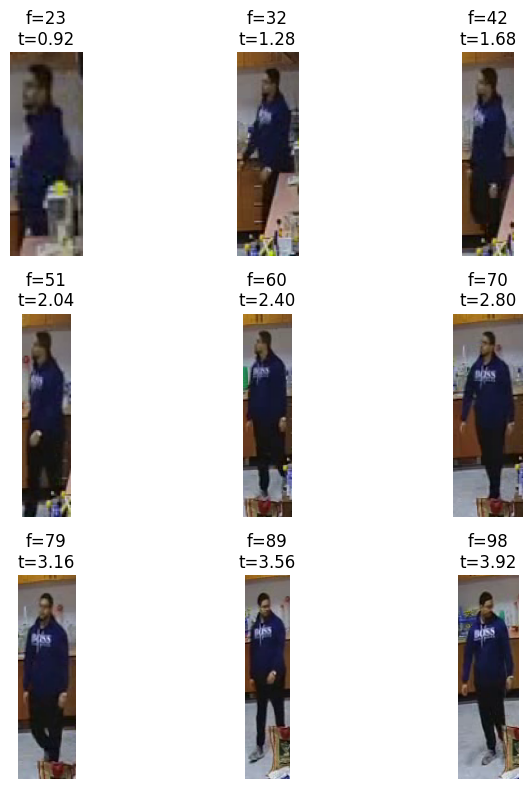

In [14]:
fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(8, 8))
axes = np.array(axes).ravel()

for idx in range(GRID_ROWS * GRID_COLS):
    axes[idx].axis("off")
    if idx < len(crops):
        crop_rgb = cv2.cvtColor(crops[idx], cv2.COLOR_BGR2RGB)
        axes[idx].imshow(crop_rgb)
        axes[idx].set_title(f"f={used_frame_indices[idx]}\nt={used_timestamps[idx]:.2f}")

plt.tight_layout()
plt.show()


## Mosaico temporal de referencia


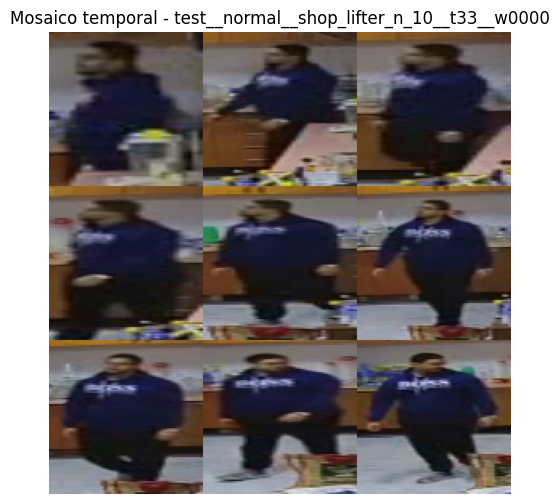

In [15]:
total_cells = GRID_ROWS * GRID_COLS
resized_crops = []

for tile_index in range(total_cells):
    if tile_index < len(crops):
        resized_crop = cv2.resize(crops[tile_index], (CROP_WIDTH, CROP_HEIGHT), interpolation=cv2.INTER_LINEAR)
    else:
        resized_crop = np.zeros((CROP_HEIGHT, CROP_WIDTH, 3), dtype=np.uint8)
    resized_crops.append(resized_crop)

mosaic_rows = []
for row_index in range(GRID_ROWS):
    start_index = row_index * GRID_COLS
    end_index = start_index + GRID_COLS
    mosaic_rows.append(np.concatenate(resized_crops[start_index:end_index], axis=1))

mosaic = np.concatenate(mosaic_rows, axis=0)
mosaic_rgb = cv2.cvtColor(mosaic, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(mosaic_rgb)
plt.title(f"Mosaico temporal - {window_spec['sample_id']}")
plt.axis("off")
plt.show()


## Construccion completa de mosaicos y manifest


In [16]:
manifest_columns = [
    "split",
    "class_name",
    "video_id",
    "video_path",
    "track_id",
    "window_id",
    "sample_id",
    "start_frame",
    "end_frame",
    "start_sec",
    "end_sec",
    "sampled_frame_indices",
    "sampled_timestamps",
    "num_frames_used",
    "mosaic_path",
    "grid_shape",
    "crop_width",
    "crop_height",
    "source_label",
    "valid_sample",
]

manifest_rows = []

for _, video_row in video_manifest_df.iterrows():
    split_name = str(video_row["split"])
    class_name = str(video_row["class_name"])
    video_id = str(video_row["video_id"])
    video_path = str(video_row["video_path"])
    video_source_path = PROJECT_ROOT / Path(video_path)
    tracks_clean_path = TRACKING_OUTPUT_DIR / split_name / video_id / "tracks_clean.csv"

    print(f"Procesando video para Modulo 3: {video_id}")

    if not tracks_clean_path.exists():
        continue

    tracks_df = pd.read_csv(tracks_clean_path)
    if tracks_df.empty:
        continue

    track_lengths_df = (
        tracks_df.groupby("track_id")
        .size()
        .reset_index(name="num_detections")
        .sort_values("track_id")
        .reset_index(drop=True)
    )
    valid_track_ids = track_lengths_df.loc[
        track_lengths_df["num_detections"] >= MIN_TRACK_LENGTH_FRAMES,
        "track_id",
    ].astype(int).tolist()

    filtered_tracks_df = tracks_df[tracks_df["track_id"].isin(valid_track_ids)].copy()
    if filtered_tracks_df.empty:
        continue

    capture = cv2.VideoCapture(str(video_source_path))
    if not capture.isOpened():
        print(f"No se pudo abrir el video: {video_source_path}")
        continue

    frame_cache = {}

    try:
        for track_id, track_df in filtered_tracks_df.groupby("track_id"):
            track_df = (
                track_df.sort_values(["frame_idx", "timestamp_sec"])
                .drop_duplicates(subset=["frame_idx"], keep="first")
                .reset_index(drop=True)
            )

            track_start_sec = float(track_df["timestamp_sec"].min())
            track_end_sec = float(track_df["timestamp_sec"].max())
            track_duration_sec = track_end_sec - track_start_sec

            if track_duration_sec <= PERSON_WINDOW_SECONDS:
                time_windows = [(round(track_start_sec, 6), round(track_end_sec, 6))]
            else:
                max_start_sec = track_end_sec - PERSON_WINDOW_SECONDS
                start_values = np.arange(track_start_sec, max_start_sec + 1e-9, PERSON_WINDOW_STRIDE_SECONDS)
                time_windows = []
                for start_sec in start_values:
                    time_windows.append(
                        (
                            round(float(start_sec), 6),
                            round(float(start_sec + PERSON_WINDOW_SECONDS), 6),
                        )
                    )

            for window_number, (start_sec, end_sec) in enumerate(time_windows):
                window_track_df = track_df[
                    (track_df["timestamp_sec"] >= start_sec)
                    & (track_df["timestamp_sec"] <= end_sec)
                ].copy()

                if window_track_df.empty:
                    sampled_rows_df = window_track_df.copy()
                elif len(window_track_df) <= FRAMES_PER_PERSON_WINDOW:
                    sampled_rows_df = window_track_df.sort_values("frame_idx").drop_duplicates(subset=["frame_idx"]).copy()
                else:
                    target_timestamps = np.linspace(start_sec, end_sec, num=FRAMES_PER_PERSON_WINDOW)
                    available_df = window_track_df.sort_values("timestamp_sec").copy()
                    selected_indices = []

                    for target_timestamp in target_timestamps:
                        remaining_df = available_df.loc[~available_df.index.isin(selected_indices)].copy()
                        if remaining_df.empty:
                            break
                        remaining_df["distance_to_target"] = (remaining_df["timestamp_sec"] - target_timestamp).abs()
                        best_row_index = remaining_df.sort_values(["distance_to_target", "frame_idx"]).index[0]
                        selected_indices.append(int(best_row_index))

                    sampled_rows_df = available_df.loc[selected_indices].sort_values("frame_idx").copy()

                if sampled_rows_df.empty:
                    start_frame = int(track_df["frame_idx"].min())
                    end_frame = int(track_df["frame_idx"].max())
                else:
                    start_frame = int(window_track_df["frame_idx"].min())
                    end_frame = int(window_track_df["frame_idx"].max())

                crops = []
                used_frame_indices = []
                used_timestamps = []

                for _, track_row in sampled_rows_df.iterrows():
                    frame_idx = int(track_row["frame_idx"])

                    if frame_idx in frame_cache:
                        frame = frame_cache[frame_idx]
                    else:
                        capture.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                        ok, frame = capture.read()
                        if not ok or frame is None:
                            continue
                        frame_cache[frame_idx] = frame

                    frame_height, frame_width = frame.shape[:2]
                    x1 = float(track_row["x1"])
                    y1 = float(track_row["y1"])
                    x2 = float(track_row["x2"])
                    y2 = float(track_row["y2"])

                    bbox_width = x2 - x1
                    bbox_height = y2 - y1
                    pad_x = bbox_width * BBOX_PADDING_RATIO
                    pad_y = bbox_height * BBOX_PADDING_RATIO

                    padded_x1 = max(0, int(round(x1 - pad_x)))
                    padded_y1 = max(0, int(round(y1 - pad_y)))
                    padded_x2 = min(frame_width, int(round(x2 + pad_x)))
                    padded_y2 = min(frame_height, int(round(y2 + pad_y)))

                    if padded_x2 <= padded_x1 or padded_y2 <= padded_y1:
                        continue

                    crop = frame[padded_y1:padded_y2, padded_x1:padded_x2]
                    if crop is None or crop.size == 0 or crop.shape[0] <= 1 or crop.shape[1] <= 1:
                        continue

                    crops.append(crop)
                    used_frame_indices.append(int(frame_idx))
                    used_timestamps.append(round(float(track_row["timestamp_sec"]), 6))

                sample_id = f"{video_id}__t{int(track_id)}__w{window_number:04d}"
                valid_sample = len(crops) >= MIN_VALID_FRAMES_PER_WINDOW
                mosaic_path_str = ""

                if valid_sample:
                    total_cells = GRID_ROWS * GRID_COLS
                    resized_crops = []

                    for tile_index in range(total_cells):
                        if tile_index < len(crops):
                            resized_crop = cv2.resize(
                                crops[tile_index],
                                (CROP_WIDTH, CROP_HEIGHT),
                                interpolation=cv2.INTER_LINEAR,
                            )
                        else:
                            resized_crop = np.zeros((CROP_HEIGHT, CROP_WIDTH, 3), dtype=np.uint8)
                        resized_crops.append(resized_crop)

                    mosaic_rows = []
                    for row_index in range(GRID_ROWS):
                        start_index = row_index * GRID_COLS
                        end_index = start_index + GRID_COLS
                        mosaic_rows.append(np.concatenate(resized_crops[start_index:end_index], axis=1))

                    mosaic = np.concatenate(mosaic_rows, axis=0)
                    mosaic_output_path = OUTPUT_DIR / split_name / class_name / f"{sample_id}.png"
                    mosaic_output_path.parent.mkdir(parents=True, exist_ok=True)
                    cv2.imwrite(str(mosaic_output_path), mosaic)
                    mosaic_path_str = mosaic_output_path.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()

                    if SAVE_DEBUG_EXAMPLES:
                        debug_tiles = []
                        for tile_index in range(total_cells):
                            if tile_index < len(crops):
                                tile = cv2.resize(
                                    crops[tile_index],
                                    (CROP_WIDTH, CROP_HEIGHT),
                                    interpolation=cv2.INTER_LINEAR,
                                ).copy()
                                frame_text = f"f:{used_frame_indices[tile_index]}"
                                time_text = f"t:{used_timestamps[tile_index]:.2f}"
                            else:
                                tile = np.zeros((CROP_HEIGHT, CROP_WIDTH, 3), dtype=np.uint8)
                                frame_text = "empty"
                                time_text = "--"

                            cv2.putText(tile, frame_text, (6, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1, cv2.LINE_AA)
                            cv2.putText(tile, time_text, (6, 36), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1, cv2.LINE_AA)
                            debug_tiles.append(tile)

                        debug_rows = []
                        for row_index in range(GRID_ROWS):
                            start_index = row_index * GRID_COLS
                            end_index = start_index + GRID_COLS
                            debug_rows.append(np.concatenate(debug_tiles[start_index:end_index], axis=1))

                        debug_mosaic = np.concatenate(debug_rows, axis=0)
                        debug_output_path = OUTPUT_DIR / "debug" / f"{video_id}_{int(track_id)}_w{window_number:04d}.jpg"
                        debug_output_path.parent.mkdir(parents=True, exist_ok=True)
                        cv2.imwrite(str(debug_output_path), debug_mosaic)

                manifest_rows.append(
                    {
                        "split": split_name,
                        "class_name": class_name,
                        "video_id": video_id,
                        "video_path": video_path,
                        "track_id": int(track_id),
                        "window_id": f"w{window_number:04d}",
                        "sample_id": sample_id,
                        "start_frame": int(start_frame),
                        "end_frame": int(end_frame),
                        "start_sec": round(float(start_sec), 6),
                        "end_sec": round(float(end_sec), 6),
                        "sampled_frame_indices": json.dumps(used_frame_indices),
                        "sampled_timestamps": json.dumps(used_timestamps),
                        "num_frames_used": int(len(crops)),
                        "mosaic_path": mosaic_path_str,
                        "grid_shape": f"{GRID_ROWS}x{GRID_COLS}",
                        "crop_width": int(CROP_WIDTH),
                        "crop_height": int(CROP_HEIGHT),
                        "source_label": class_name,
                        "valid_sample": bool(valid_sample),
                    }
                )
    finally:
        capture.release()

manifest_df = pd.DataFrame(manifest_rows, columns=manifest_columns)
if manifest_df.empty:
    manifest_df = pd.DataFrame(columns=manifest_columns)
else:
    manifest_df = manifest_df.sort_values(
        ["split", "class_name", "video_id", "track_id", "window_id"]
    ).reset_index(drop=True)

person_window_manifest_path = OUTPUT_DIR / "person_window_manifest.csv"
manifest_df.to_csv(person_window_manifest_path, index=False)

valid_manifest_df = manifest_df[manifest_df["valid_sample"] == True].copy()

print(person_window_manifest_path)
print(f"Filas totales en person_window_manifest.csv: {len(manifest_df)}")
print(f"Muestras validas: {len(valid_manifest_df)}")

if valid_manifest_df.empty:
    raise RuntimeError("No se generaron muestras validas para el Modulo 4.")

display(
    valid_manifest_df.groupby(["split", "source_label"])
    .size()
    .reset_index(name="num_samples")
    .sort_values(["split", "source_label"])
    .reset_index(drop=True)
)

display(
    valid_manifest_df.groupby(["split", "source_label"])
    .agg(
        videos_cubiertos=("video_id", "nunique"),
        tracks_cubiertos=("track_id", "nunique"),
        ventanas=("window_id", "size"),
    )
    .reset_index()
)

split_counts = valid_manifest_df.groupby("split").size().to_dict()
missing_splits = [split_name for split_name in ["train", "val", "test"] if split_counts.get(split_name, 0) == 0]
if missing_splits:
    raise ValueError(f"El person_window_manifest.csv quedo incompleto para los splits: {missing_splits}.")

Procesando video para Modulo 3: test__hurto_simulado__shop_lifter_46
Procesando video para Modulo 3: test__hurto_simulado__shop_lifter_80
Procesando video para Modulo 3: test__hurto_simulado__shop_lifter_95
Procesando video para Modulo 3: test__normal__shop_lifter_n_0_1
Procesando video para Modulo 3: test__normal__shop_lifter_n_10
Procesando video para Modulo 3: test__normal__shop_lifter_n_196
Procesando video para Modulo 3: test__normal__shop_lifter_n_39
Procesando video para Modulo 3: test__normal__shop_lifter_n_49
Procesando video para Modulo 3: train__hurto_simulado__shop_lifter_100
Procesando video para Modulo 3: train__hurto_simulado__shop_lifter_12
Procesando video para Modulo 3: train__hurto_simulado__shop_lifter_16
Procesando video para Modulo 3: train__hurto_simulado__shop_lifter_18
Procesando video para Modulo 3: train__hurto_simulado__shop_lifter_23
Procesando video para Modulo 3: train__hurto_simulado__shop_lifter_26
Procesando video para Modulo 3: train__hurto_simulado__

,split,source_label,num_samples
0,test,hurto_simulado,16
1,test,normal,34
2,train,hurto_simulado,61
3,train,normal,89
4,val,hurto_simulado,18
5,val,normal,25


,split,source_label,videos_cubiertos,tracks_cubiertos,ventanas
0,test,hurto_simulado,3,5,16
1,test,normal,5,5,34
2,train,hurto_simulado,12,18,61
3,train,normal,22,28,89
4,val,hurto_simulado,3,5,18
5,val,normal,4,4,25
